# 02 — Data Understanding (RH)

**Objetivo:** ler as bases, integrar (join), checar qualidade e levantar insights iniciais relacionados à **Rotatividade**.

> Este notebook não faz transformações para modelagem. Ele produz um dataset integrado em `data/interim/rh_joined.csv` (ou `.parquet`) para ser usado nas próximas etapas.


### 2.1 Setup

In [74]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


### 2.2 Leitura das bases (raw)

Coloque os arquivos em `data/raw/` conforme README.

- `tb_rh_funcionarios.csv`
- `tb_rh_pesquisa_funcionarios.csv`
- `tb_rh_pesquisa_gestores.csv`


In [79]:
from pathlib import Path

DATA_RAW = Path("../data/raw")
DATA_INTERIM = Path("../data/interim")
DATA_INTERIM.mkdir(parents=True, exist_ok=True)

df_rh_funcionarios = pd.read_csv(DATA_RAW / "tb_rh_funcionarios.csv", engine="pyarrow")
df_rh_pesquisa_funcionarios = pd.read_csv(DATA_RAW / "tb_rh_pesquisa_funcionarios.csv", engine="pyarrow")
df_rh_pesquisa_gestores = pd.read_csv(DATA_RAW / "tb_rh_pesquisa_gestores.csv", engine="pyarrow")

(df_rh_funcionarios.shape, df_rh_pesquisa_funcionarios.shape, df_rh_pesquisa_gestores.shape)

((4410, 24), (4410, 4), (4410, 3))

### 2.3 Visão geral (schema + nulos)

In [80]:
def quick_profile(df, name):
    print(f"\n=== {name} ===")
    display(df.head(3))
    print(df.shape)
    display(df.info())
    missing = df.isna().mean().sort_values(ascending=False)
    display(missing[missing>0].to_frame("pct_null"))

quick_profile(df_rh_funcionarios, "tb_rh_funcionarios")
quick_profile(df_rh_pesquisa_funcionarios, "tb_rh_pesquisa_funcionarios")
quick_profile(df_rh_pesquisa_gestores, "tb_rh_pesquisa_gestores")



=== tb_rh_funcionarios ===


,Idade,Rotatividade,ViagensDeNegocio,Departamento,DistanciaDeCasa,Educacao,CampoDeEducacao,ContagemDeEmpregados,IDDoEmpregado,Genero,NivelDoCargo,Funcao,EstadoCivil,RendaMensal,NumeroDeEmpresas,MaiorDe18,AumentoPercentualSalario,HorasPadrao,NivelDeOpcaoDeCompraDeAcoes,TotalDeAnosTrabalhados,TreinamentosNoUltimoAno,AnosNaEmpresa,AnosDesdeUltimaPromocao,AnosComAtualGestor
0,51,Nao,Viagens_Raras,Vendas,6,2,Ciências da Vida,1,1,Feminino,1,Representante de Saúde,Casado(a),26232.0,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Sim,Viagens_Frequentes,Pesquisa_e_Desenvolvimento,10,1,Ciências da Vida,1,2,Feminino,1,Cientista de Pesquisa,Solteiro(a),8378.0,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,Nao,Viagens_Frequentes,Pesquisa_e_Desenvolvimento,17,4,Outro,1,3,Masculino,4,Executivo de Vendas,Casado(a),38656.0,1.0,Y,15,8,3,5.0,2,5,0,3


(4410, 24)
<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Idade                        4410 non-null   int64  
 1   Rotatividade                 4410 non-null   str    
 2   ViagensDeNegocio             4410 non-null   str    
 3   Departamento                 4410 non-null   str    
 4   DistanciaDeCasa              4410 non-null   int64  
 5   Educacao                     4410 non-null   int64  
 6   CampoDeEducacao              4410 non-null   str    
 7   ContagemDeEmpregados         4410 non-null   int64  
 8   IDDoEmpregado                4410 non-null   int64  
 9   Genero                       4410 non-null   str    
 10  NivelDoCargo                 4410 non-null   int64  
 11  Funcao                       4410 non-null   str    
 12  EstadoCivil                  4410 non-null   str    
 13  RendaMensal       

None

,pct_null
NumeroDeEmpresas,0.004308
TotalDeAnosTrabalhados,0.002041


...


=== tb_rh_pesquisa_gestores ===


,IDDoEmpregado,EnvolvimentoNoTrabalho,AvaliacaoDeDesempenho
0,1,3,3
1,2,2,4
2,3,3,3


(4410, 3)
<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   IDDoEmpregado           4410 non-null   int64
 1   EnvolvimentoNoTrabalho  4410 non-null   int64
 2   AvaliacaoDeDesempenho   4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB


None

,pct_null


### 2.4 Join entre tabelas

Chave esperada: `IDDoEmpregado` (como no notebook base). Se a base usar outro nome, ajuste aqui.


In [82]:
KEY = "IDDoEmpregado"

df_aux1 = pd.merge(df_rh_funcionarios, df_rh_pesquisa_funcionarios, on=KEY, how="left")
df_publico = pd.merge(df_aux1, df_rh_pesquisa_gestores, on=KEY, how="left")

df_publico.shape


(4410, 29)

In [84]:
df_publico.head()

,Idade,Rotatividade,ViagensDeNegocio,Departamento,DistanciaDeCasa,Educacao,CampoDeEducacao,ContagemDeEmpregados,IDDoEmpregado,Genero,NivelDoCargo,Funcao,EstadoCivil,RendaMensal,NumeroDeEmpresas,MaiorDe18,AumentoPercentualSalario,HorasPadrao,NivelDeOpcaoDeCompraDeAcoes,TotalDeAnosTrabalhados,TreinamentosNoUltimoAno,AnosNaEmpresa,AnosDesdeUltimaPromocao,AnosComAtualGestor,SatisfacaoComAmbiente,SatisfacaoNoTrabalho,EquilibrioTrabalhoVida,EnvolvimentoNoTrabalho,AvaliacaoDeDesempenho
0,51,Nao,Viagens_Raras,Vendas,6,2,Ciências da Vida,1,1,Feminino,1,Representante de Saúde,Casado(a),26232.0,1.0,Y,11,8,0,1.0,6,1,0,0,3.0,4.0,2.0,3,3
1,31,Sim,Viagens_Frequentes,Pesquisa_e_Desenvolvimento,10,1,Ciências da Vida,1,2,Feminino,1,Cientista de Pesquisa,Solteiro(a),8378.0,0.0,Y,23,8,1,6.0,3,5,1,4,3.0,2.0,4.0,2,4
2,32,Nao,Viagens_Frequentes,Pesquisa_e_Desenvolvimento,17,4,Outro,1,3,Masculino,4,Executivo de Vendas,Casado(a),38656.0,1.0,Y,15,8,3,5.0,2,5,0,3,2.0,2.0,1.0,3,3
3,38,Nao,Nao_Viaja,Pesquisa_e_Desenvolvimento,2,5,Ciências da Vida,1,4,Masculino,3,Recursos Humanos,Casado(a),16642.0,3.0,Y,11,8,3,13.0,5,8,7,5,4.0,4.0,3.0,2,3
4,32,Nao,Viagens_Raras,Pesquisa_e_Desenvolvimento,10,1,Médica,1,5,Masculino,1,Executivo de Vendas,Solteiro(a),4684.0,4.0,Y,12,8,2,9.0,2,6,0,4,4.0,1.0,3.0,3,3


### 2.5 Qualidade básica

- Duplicados
- Nulos
- Cardinalidade de algumas colunas


In [85]:
dup = df_publico.duplicated().sum()
missing = df_publico.isna().mean().sort_values(ascending=False)

print("Duplicados:", dup)
display(missing[missing>0].to_frame("pct_null").head(20))

# Cardinalidade (para ter noção de variáveis categóricas)
cat_cols = df_publico.select_dtypes(include="object").columns
card = df_publico[cat_cols].nunique().sort_values(ascending=False)
display(card.to_frame("n_unique").head(20))


Duplicados: 0


,pct_null
EquilibrioTrabalhoVida,0.008617
SatisfacaoComAmbiente,0.005669
SatisfacaoNoTrabalho,0.004535
NumeroDeEmpresas,0.004308
TotalDeAnosTrabalhados,0.002041


,n_unique
Funcao,9
CampoDeEducacao,6
Departamento,3
ViagensDeNegocio,3
EstadoCivil,3
Rotatividade,2
Genero,2
MaiorDe18,1


### 2.6 Target (Rotatividade)

A coluna target é **Rotatividade** com valores tipicamente `Sim/Não`.


In [86]:
target_col = "Rotatividade"
df_publico[target_col].value_counts(dropna=False)

Rotatividade
Nao    3699
Sim     711
Name: count, dtype: int64

In [87]:
rot_pct = df_publico[target_col].value_counts(normalize=True).mul(100).round(2)
rot_pct

Rotatividade
Nao    83.88
Sim    16.12
Name: proportion, dtype: float64

### 2.7 Análises rápidas orientadas ao target

A ideia aqui é gerar **hipóteses** (não conclusões finais).


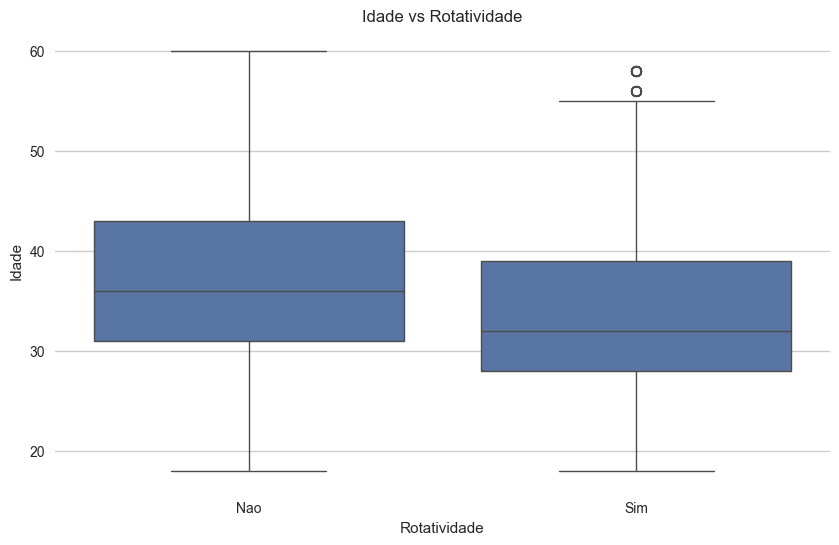

<Figure size 1000x600 with 0 Axes>

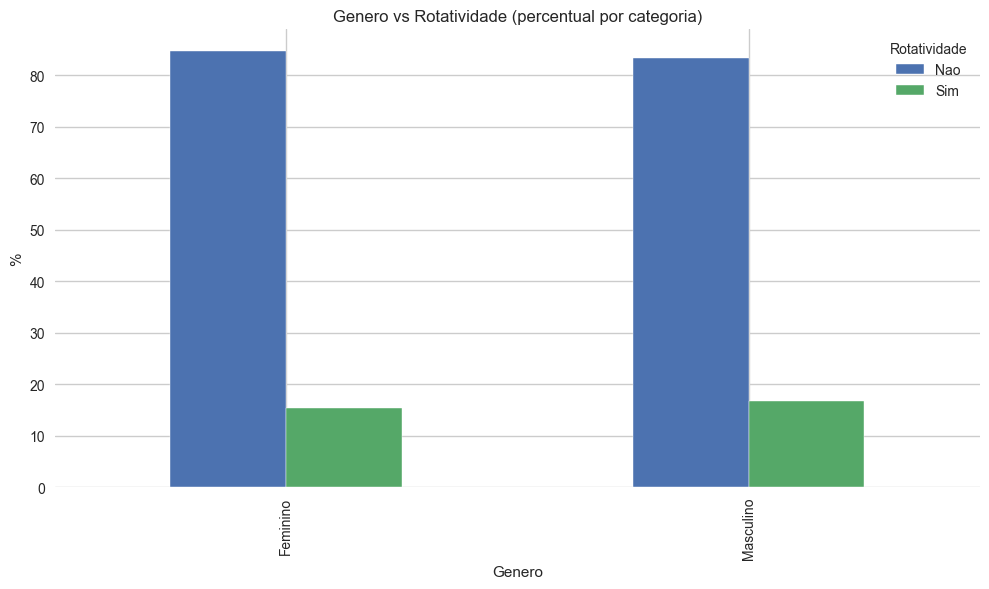

In [89]:
# Exemplo: Idade x Rotatividade (ajuste o nome se necessário)
if "Idade" in df_publico.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df_publico, x=target_col, y="Idade")
    plt.title("Idade vs Rotatividade")
    plt.show()

# Exemplo: Gênero x Rotatividade
for col in ["Genero", "Gênero", "Sexo"]:
    if col in df_publico.columns:
        plt.figure(figsize=(10,6))
        ct = (pd.crosstab(df_publico[col], df_publico[target_col], normalize='index')*100).round(1)
        ct.plot(kind="bar", figsize=(10,6))
        plt.title(f"{col} vs Rotatividade (percentual por categoria)")
        plt.ylabel("%")
        plt.legend(title="Rotatividade")
        plt.tight_layout()
        plt.show()
        break


### 2.8 Persistência do dataset integrado (interim)

Este arquivo será a entrada padrão do pipeline (preparo/modelagem).


In [90]:
out_csv = DATA_INTERIM / "rh_joined.csv"
df_publico.to_csv(out_csv, index=False)
print("OK ->", out_csv)


OK -> ..\data\interim\rh_joined.csv
